In [1]:
from datetime import datetime
from time import sleep
import urllib.request
from bs4 import BeautifulSoup
import re
import pandas as pd
# import importlib
# importlib.reload(mrc)
import myrace as mrc
from mycolor import *

def RacePiGraph(rc_xxR):
    """ Scraping """
    race_url="https://race.netkeiba.com/?pid=race_old&id=c2019" + rc_xxR # rc.grc("阪神sat") + "12"

    cal_html = urllib.request.urlopen(race_url)
    cal_soup = BeautifulSoup(cal_html,"lxml")
    cal_df = pd.io.html.read_html(cal_soup.prettify())
    entries_df = cal_df[0]
    entries_df.columns = entries_df.columns.droplevel() # 表示の項目名が２重になっているため

    """ レース情報の取得 """
    data_soup = cal_soup.find("dl", class_="racedata fc")
    other_soup = cal_soup.find("div", class_="race_otherdata")
    race_course = other_soup.find_all("p")[1].string
    race_course = re.sub("\d+回", "", race_course)[:2]
    race_no = re.sub("\n", "", data_soup.find("dt").string)
    race_name = re.sub("<[^>]*?>", "", str(data_soup.find("h1")))
    race_name = re.sub("\xa0", "", race_name)
    print(Color.Blue + "{} {} {}".format(race_course, race_no, race_name), end=" ") 
    print(other_soup.find_all("p")[2].string + Color.End) # (国際)牝(指定)馬齢 12頭
    print(Color.Green + data_soup.find_all("p")[0].string, end=" ") # 芝1800m (右 外) 
    print(data_soup.find_all("p")[1].string + Color.End) # 天気：晴 / 馬場：良 / 発走：15:35

    """ オッズ情報の取得 """
    odds_lst= []
    idx_lst = []
    for i, odds in enumerate(entries_df['単勝  オッズ']):
        if(type(odds) != str):
            odds_lst.append(odds)
            idx_lst.append(i)
        elif('.' in odds):  # 取消が含まれていると全ての要素がstr型になる
            odds_lst.append(float(odds))
            idx_lst.append(i)
        else:
            print(Color.White + "{} 番: {} のため除外".format(i+1, odds) + Color.End)

    """ 支持率 """
    sort_odds = sorted(odds_lst) # odds_lstは以下で要素を削除される
    popular_rate = [round((0.8 / ods)*100, 2) for ods in sort_odds] # 単勝控除率0.8
    remaining_rate = popular_rate[1:] # 1番人気を除いた支持率

    """ 1番人気 """
    idx1 = idx_lst[(odds_lst.index(min(odds_lst)))]
    most_popular_hourse = str(entries_df['馬  番'][idx1]).rjust(2,"0") + " " + entries_df['馬名'][idx1] \
                        + " " + entries_df['騎手'][idx1] + " " + str(entries_df['単勝  オッズ'][idx1]) + "倍"
    """ 2番人気 """
    del odds_lst[idx1]
    del idx_lst[idx1]
    idx2 = idx_lst[(odds_lst.index(min(odds_lst)))]
    second_popular_hourse = str(entries_df['馬  番'][idx2]).rjust(2,"0") + " " + entries_df['馬名'][idx2] \
                        + " " + entries_df['騎手'][idx2] + " " + str(entries_df['単勝  オッズ'][idx2]) + "倍"

    print(Color.Yellow + "1番人気:", most_popular_hourse + Color.End, end=" / ")
    print(Color.Cyan + "2番人気:", second_popular_hourse + Color.End)
    print(sort_odds)

    """ 支持率（オッズ）グラフ """
    plt.figure(figsize=(12, 6), facecolor="#7b68ee") # darkslategray
    plt.rcParams["font.family"] = "IPAexGothic"

    plt.subplot(1,2,1)
    plt.title('単勝支持率', fontsize=16)
    plt.pie(popular_rate)

    plt.subplot(1,2,2)
    plt.title('2着以降の支持率', fontsize=16)
    plt.pie(remaining_rate)

    plt.show()
    display(mrc.poplink(race_url))

print("code loading ", datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

code loading  2019/10/06 00:52:04


In [4]:
rc = mrc.Rcd("阪神sun")

race_url="https://race.netkeiba.com/?pid=race_old&id=c2019" + rc.grc() + "02"

cal_html = urllib.request.urlopen(race_url)
cal_soup = BeautifulSoup(cal_html,"lxml")
cal_df = pd.io.html.read_html(cal_soup.prettify())
entries_df = cal_df[0]
entries_df.columns = entries_df.columns.droplevel() # 表示の項目名が２重になっているため
entries_df

,枠 番,馬 番,馬名,性齢,負担 重量,騎手,厩舎,馬体重,予想 オッズ,人 気
0,1,1,アジャストザルート,牡2,54.0,池添,池添学,NaN,8.4,5
1,2,2,リインフォース,牡2,54.0,松山,石坂公,NaN,7.7,4
2,3,3,テイエムプリジャン,牡2,51.0,岩田望,五十嵐,NaN,11.6,7
3,4,4,ゴルトファルベン,牡2,54.0,Ｍデムーロ,吉村,NaN,2.4,1
4,5,5,ラインオブダンス,牝2,53.0,坂井,矢作,NaN,4.1,2
5,6,6,シェイクスピア,牡2,54.0,藤岡康,西浦,NaN,21.8,8
6,7,7,パラパラ,牝2,54.0,吉田隼,作田,NaN,27.5,9
7,8,8,リノ,牝2,51.0,斎藤,寺島,NaN,5.4,3
8,8,9,アルマフォルト,牡2,54.0,和田,木原,NaN,9.2,6


新潟 1R ２歳未勝利 混[指定] 12頭
芝2000m (左) 天気：曇 / 馬場：良 / 発走：09:55
1番人気: 03 ワスカランテソーロ 柴山 2.4倍 / 2番人気: 05 ロードオマージュ 菅原明 5.9倍
[2.4, 5.9, 6.1, 6.4, 12.7, 16.1, 19.9, 21.0, 33.4, 65.8, 89.6, 147.7]


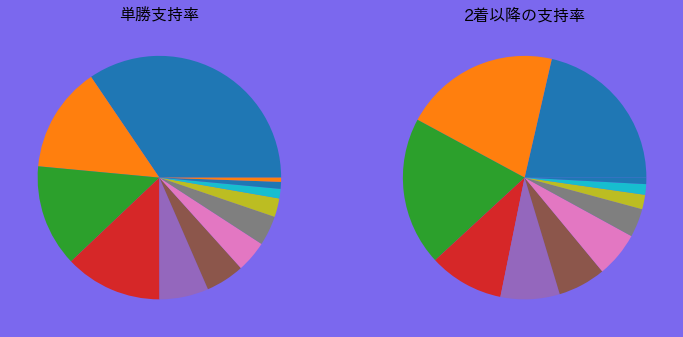

京都 1R ２歳未勝利 [指定] 12頭
ダ1200m (右) 天気：晴 / 馬場：良 / 発走：10:05
1番人気: 02 レインボーメイプル 松若 4.2倍 / 2番人気: 03 ベッロコルサ 北村友 4.5倍
[4.2, 4.5, 7.8, 8.6, 9.2, 9.7, 11.6, 13.8, 15.9, 28.5, 56.9, 175.9]


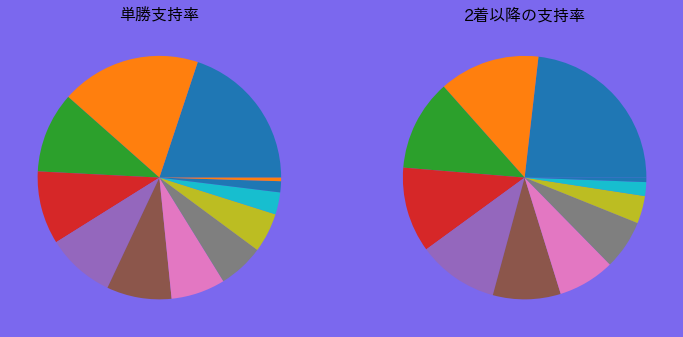

新潟 2R ２歳未勝利 牝[指定] 14頭
ダ1200m (左) 天気：曇 / 馬場：稍重 / 発走：10:25
1番人気: 11 アルカウン 藤田菜 2.3倍 / 2番人気: 08 テーオープライム 斎藤 4.7倍
[2.3, 4.7, 6.8, 7.7, 12.9, 25.1, 29.0, 34.3, 39.2, 57.8, 64.3, 72.6, 72.6, 104.7]


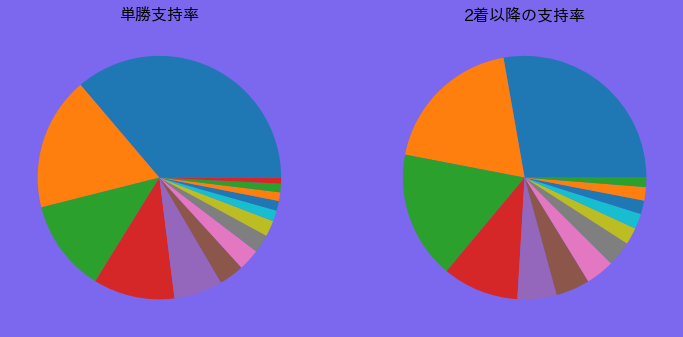

京都 2R ２歳未勝利 [指定] 16頭
ダ1800m (右) 天気：晴 / 馬場：良 / 発走：10:35
1番人気: 04 スマートコマンダー 藤井勘 3.9倍 / 2番人気: 16 タマモパッション 三浦 6.2倍
[3.9, 6.2, 7.0, 9.9, 11.1, 12.3, 12.7, 16.1, 23.1, 26.1, 29.5, 37.2, 42.5, 44.9, 51.4, 101.5]


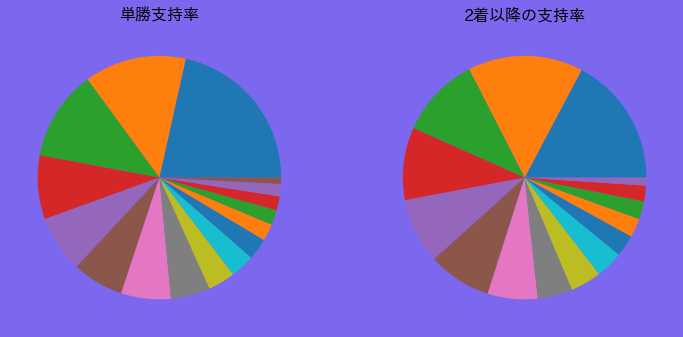

新潟 3R ３歳以上１勝クラス 混[指定]定量 15頭
ダ1800m (左) 天気：曇 / 馬場：稍重 / 発走：10:55
1番人気: 10 カセノウィナー 丸山 4.2倍 / 2番人気: 01 フクノワイルド 加藤 5.0倍
[4.2, 5.0, 5.9, 9.8, 11.6, 14.0, 16.7, 18.6, 19.6, 20.7, 23.2, 23.7, 26.0, 27.5, 53.6]


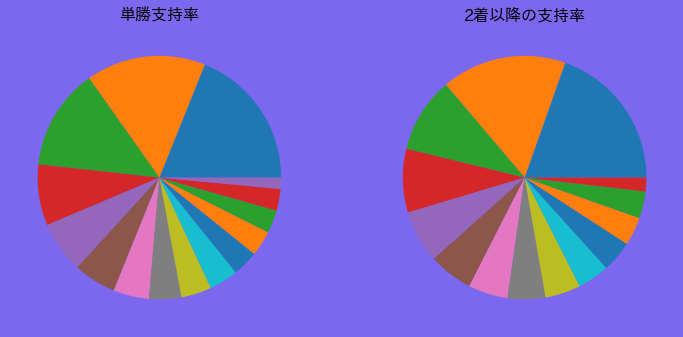

京都 3R ２歳未勝利 混[指定] 9頭
芝1600m (右) 天気：晴 / 馬場：良 / 発走：11:05
1番人気: 08 スターズプレミア 浜中 2.2倍 / 2番人気: 09 アージオン Ｍデムーロ 3.2倍
[2.2, 3.2, 7.0, 8.2, 14.7, 15.5, 64.2, 85.4, 103.1]


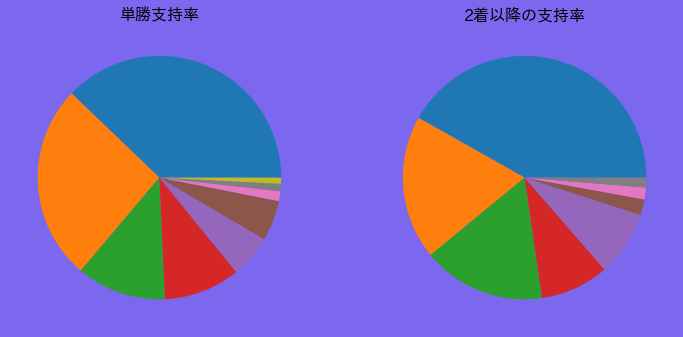

新潟 4R ３歳以上障害未勝利 定量 13頭
障2850m (芝 外-内) 天気：曇 / 馬場：稍重 / 発走：11:25
1番人気: 02 ラインスピリット 森一 2.5倍 / 2番人気: 07 ビーハグ 山本 4.9倍
[2.5, 4.9, 5.6, 8.3, 9.1, 15.9, 16.4, 24.9, 34.8, 49.9, 54.7, 63.8, 114.9]


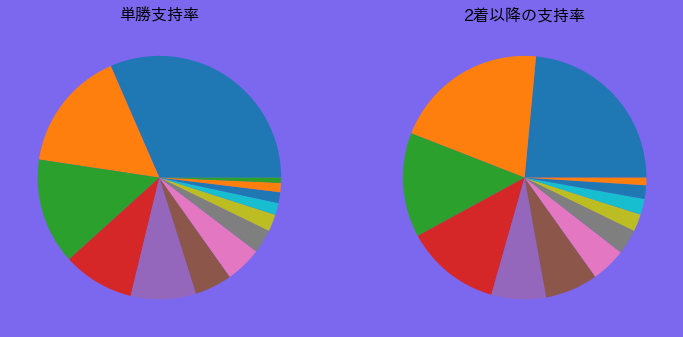

京都 4R ２歳新馬 [指定] 16頭
ダ1800m (右) 天気：晴 / 馬場：良 / 発走：11:35
1番人気: 07 ダノンアレー 北村友 4.3倍 / 2番人気: 01 ベルダーイメル 横山典 5.2倍
[4.3, 5.2, 6.6, 7.9, 10.4, 10.5, 12.0, 21.0, 30.3, 33.0, 36.2, 40.5, 48.6, 92.2, 100.3, 148.3]


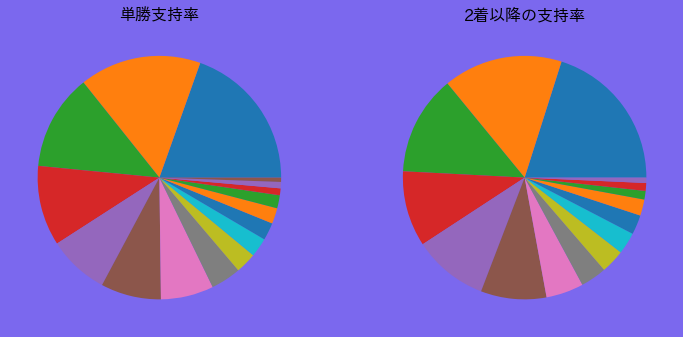

新潟 5R ２歳新馬 混[指定] 15頭
ダ1200m (左) 天気：曇 / 馬場：稍重 / 発走：12:15
1番人気: 01 スイスライツ 藤田菜 3.7倍 / 2番人気: 06 トウカイマナ 柴田善 5.7倍
[3.7, 5.7, 11.3, 12.5, 13.2, 14.9, 15.8, 16.0, 16.5, 17.1, 18.9, 22.8, 30.1, 32.1, 34.9]


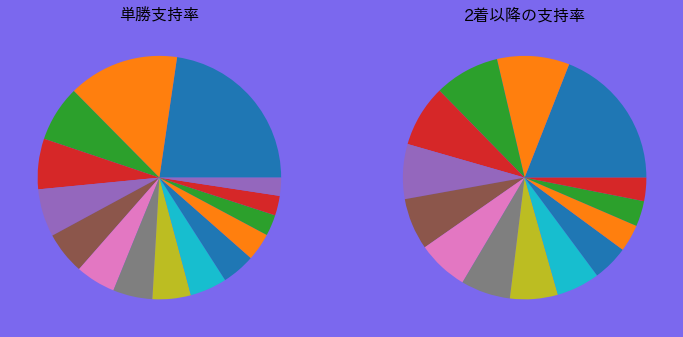

京都 5R ２歳新馬 混[指定] 16頭
芝2000m (右) 天気：晴 / 馬場：良 / 発走：12:25
1番人気: 06 ヒュッゲ 岩田康 5.7倍 / 2番人気: 16 サトノパシュート 浜中 5.8倍
[5.7, 5.8, 6.5, 6.8, 7.0, 10.2, 10.4, 24.2, 30.3, 31.1, 36.4, 55.2, 65.6, 68.4, 78.2, 149.2]


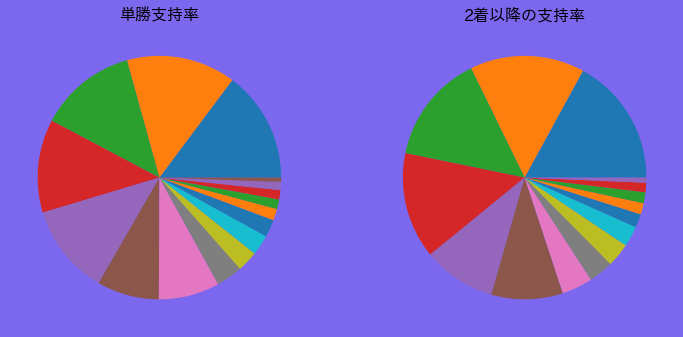

新潟 6R ２歳未勝利 [指定] 16頭
芝1000m (直線) 天気：曇 / 馬場：良 / 発走：12:45
1番人気: 07 サノチナ 藤田菜 4.8倍 / 2番人気: 15 ジュニパーベリー 嶋田 5.9倍
[4.8, 5.9, 7.2, 7.2, 9.7, 12.0, 12.1, 12.9, 15.1, 20.1, 34.9, 83.5, 97.0, 136.6, 136.6, 150.3]


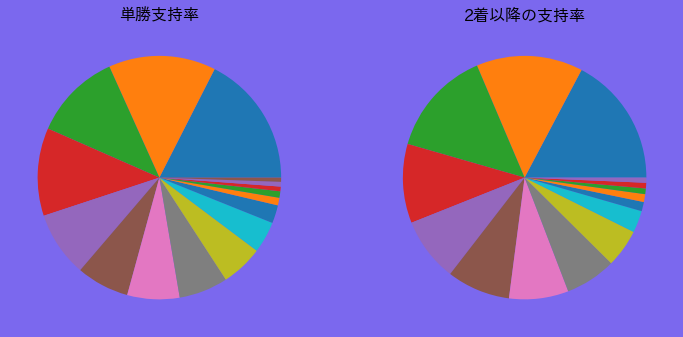

京都 6R ３歳以上１勝クラス 牝[指定]定量 7頭
ダ1800m (右) 天気：晴 / 馬場：良 / 発走：12:55
1番人気: 02 オーパスメーカー 太宰 1.9倍 / 2番人気: 03 ソルファ 三浦 3.5倍
[1.9, 3.5, 6.0, 8.4, 12.7, 16.9, 36.6]


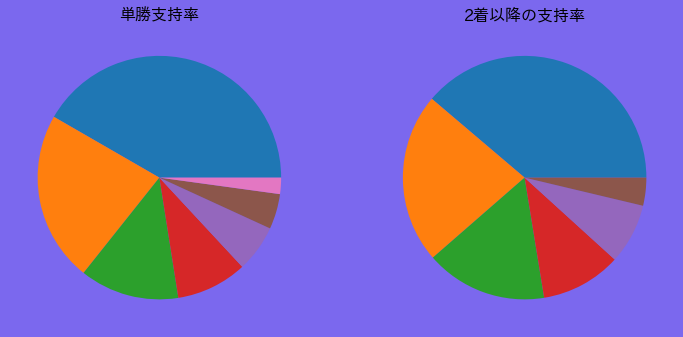

新潟 7R ３歳以上１勝クラス （若手騎手）定量 15頭
ダ1200m (左) 天気：曇 / 馬場：稍重 / 発走：13:15
1番人気: 09 グラウクス 藤田菜 2.3倍 / 2番人気: 06 ドロウアカード 斎藤 6.9倍
[2.3, 6.9, 8.7, 9.2, 10.4, 13.3, 17.3, 17.9, 27.8, 27.8, 32.0, 36.3, 53.4, 60.1, 71.2]


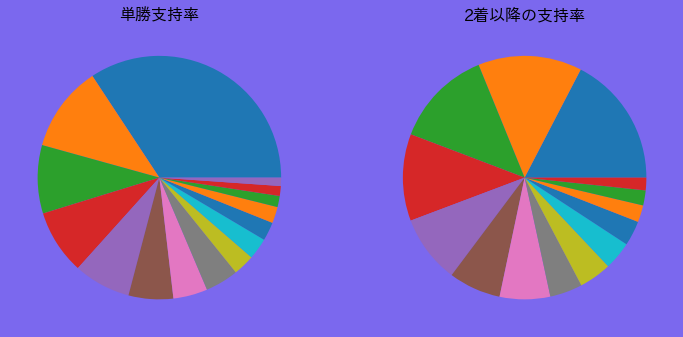

京都 7R ３歳以上１勝クラス [指定]定量 13頭
ダ1400m (右) 天気：晴 / 馬場：良 / 発走：13:25
1番人気: 08 トップウイナー 岩田康 2.9倍 / 2番人気: 12 ミトノブラック 松山 5.9倍
[2.9, 5.9, 7.7, 8.5, 8.6, 9.1, 11.7, 22.4, 25.0, 30.4, 41.8, 48.4, 53.3]


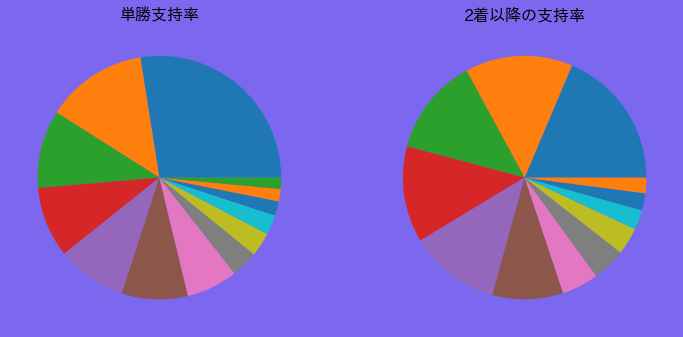

新潟 8R ３歳以上１勝クラス [指定]定量 9頭
ダ2500m (左) 天気：曇 / 馬場：稍重 / 発走：13:45
1番人気: 02 ネコマヒカ 藤田菜 2.6倍 / 2番人気: 04 レシプロケイト 丸山 2.9倍
[2.6, 2.9, 6.0, 7.2, 12.3, 18.5, 21.1, 30.3, 55.5]


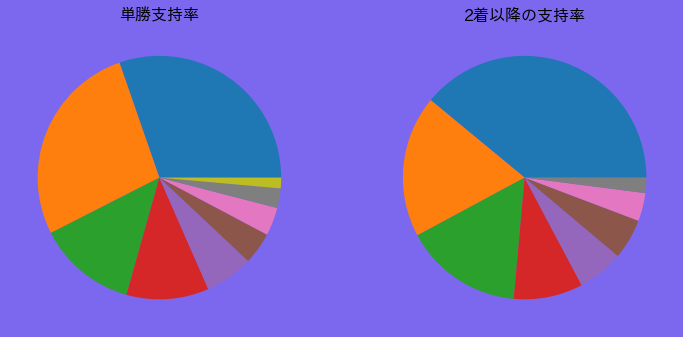

京都 8R ３歳以上１勝クラス [指定]定量 15頭
芝1600m (右 外) 天気：晴 / 馬場：良 / 発走：13:55
1番人気: 14 モズレジーナ 松山 2.8倍 / 2番人気: 13 トップオブメジャー 藤岡康 5.8倍
[2.8, 5.8, 6.5, 8.8, 10.3, 16.9, 17.0, 19.4, 23.0, 24.2, 27.3, 30.6, 41.7, 87.7, 118.3]


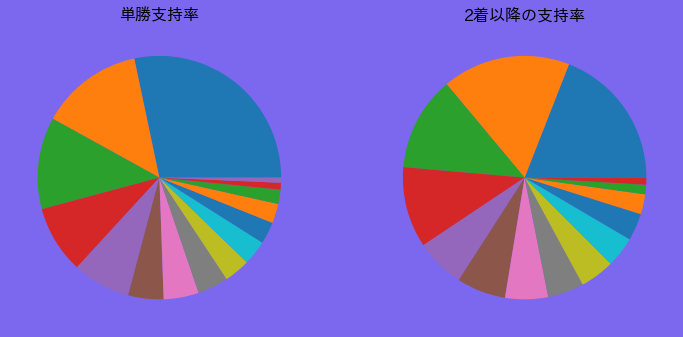

新潟 9R ３歳以上１勝クラス [指定]定量 15頭
芝2000m (左 外) 天気：曇 / 馬場：良 / 発走：14:15
1番人気: 12 アースドラゴン 藤田菜 4.4倍 / 2番人気: 03 ジャストアジゴロ 斎藤 5.5倍
[4.4, 5.5, 5.7, 6.9, 8.2, 9.8, 10.7, 15.4, 23.5, 40.6, 45.0, 51.4, 54.8, 93.3, 93.3]


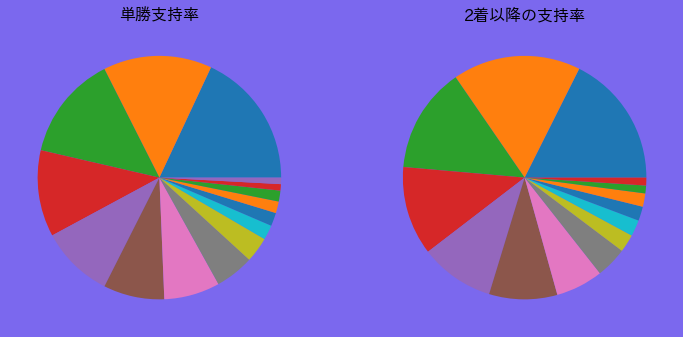

京都 9R 清滝特別 ３歳上２勝クラス混[指定]ハンデ 8頭
芝1800m (右 外) 天気：晴 / 馬場：良 / 発走：14:25
1番人気: 03 カリボール Ｍデムーロ 1.3倍 / 2番人気: 01 メイショウカミシマ 横山典 5.8倍
[1.3, 5.8, 6.3, 16.8, 19.9, 26.5, 27.5, 43.6]


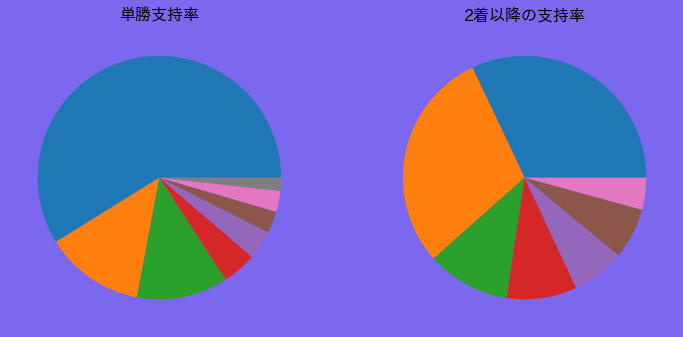

新潟 10R 粟島特別 ３歳上１勝クラス混[指定]定量 10頭
芝1800m (左 外) 天気：曇 / 馬場：良 / 発走：14:50
1番人気: 10 ナスノシンフォニー 吉田隼 1.1倍 / 2番人気: 03 エピックスター 藤田菜 16.1倍
[1.1, 16.1, 18.9, 21.2, 22.0, 23.3, 27.2, 38.9, 65.0, 97.1]


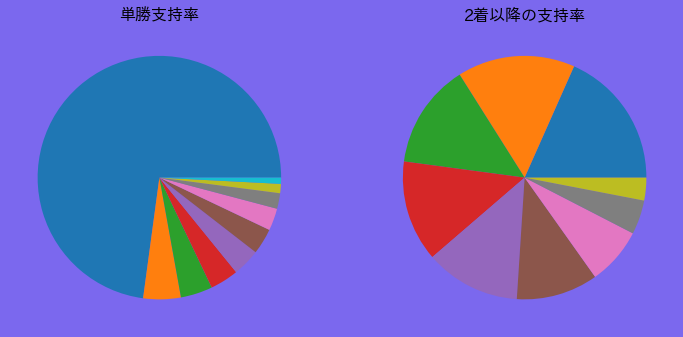

京都 10R 藤森Ｓ ３歳上３勝クラス混(特指)定量 13頭
ダ1200m (右) 天気：晴 / 馬場：良 / 発走：15:00
1番人気: 11 デザートストーム 藤岡康 2.3倍 / 2番人気: 08 リュウノユキナ 横山典 5.2倍
[2.3, 5.2, 8.2, 11.3, 13.0, 16.5, 17.1, 17.9, 18.4, 19.4, 25.1, 46.8, 83.3]


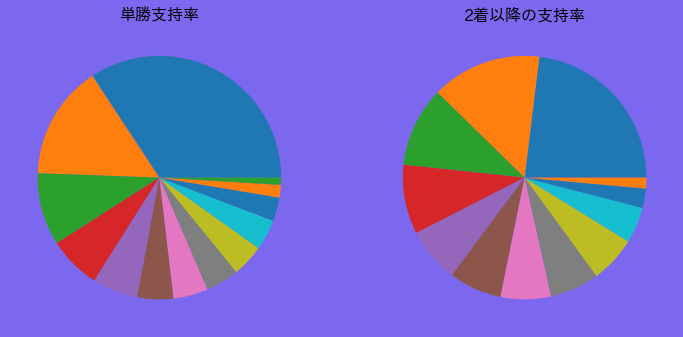

新潟 11R 信越Ｓ (国際)(特指)ハンデ 17頭
芝1400m (左) 天気：曇 / 馬場：良 / 発走：15:25
1番人気: 17 リバティハイツ 丸田 5.5倍 / 2番人気: 07 アンコールプリュ 横山武 6.6倍
[5.5, 6.6, 6.8, 6.9, 7.7, 8.4, 12.4, 17.2, 18.5, 23.1, 23.5, 32.2, 40.7, 50.5, 63.6, 114.9, 206.4]


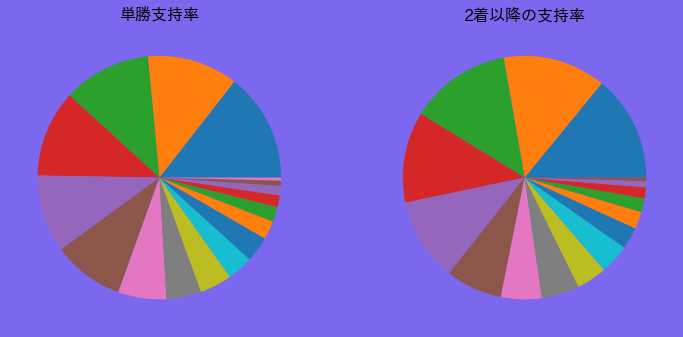

京都 11R 京都大賞典 (国際)(指定)別定 17頭
芝2400m (右 外) 天気：晴 / 馬場：良 / 発走：15:35
1番人気: 16 グローリーヴェイズ Ｍデムーロ 1.9倍 / 2番人気: 04 エタリオウ 横山典 5.3倍
[1.9, 5.3, 7.0, 11.6, 13.0, 15.7, 19.4, 39.2, 40.1, 44.9, 69.2, 102.7, 103.2, 117.4, 122.2, 137.8, 219.1]


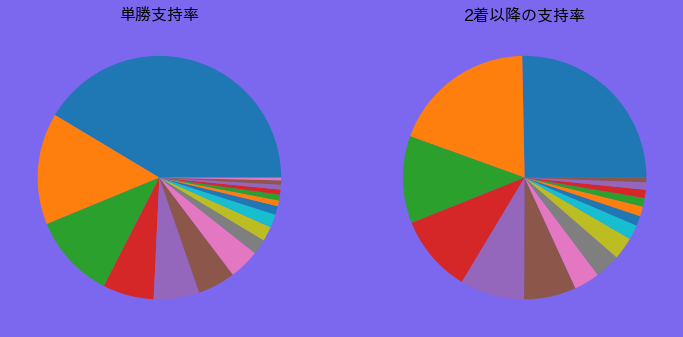

新潟 12R 菅名岳特別 ３歳上２勝クラス牝[指定]定量 15頭
ダ1800m (左) 天気：曇 / 馬場：稍重 / 発走：16:00
1番人気: 06 グラマラスライフ 丸山 3.4倍 / 2番人気: 03 タイトロープウィン 柴田善 6.6倍
[3.4, 6.6, 8.8, 9.3, 10.3, 10.6, 11.9, 15.7, 17.9, 19.2, 25.9, 28.9, 34.2, 43.9, 57.4]


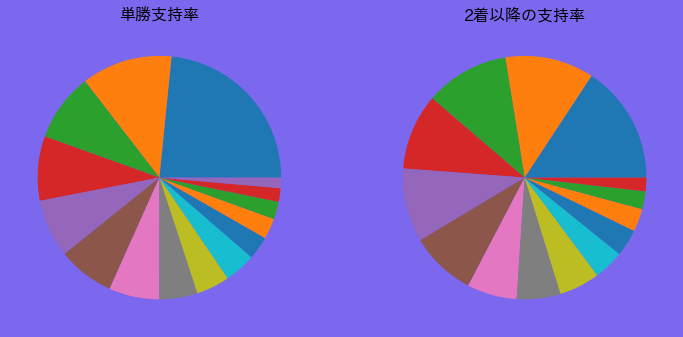

京都 12R ３歳以上２勝クラス 混[指定]定量 14頭
芝1200m (右) 天気：晴 / 馬場：良 / 発走：16:10
1番人気: 07 マリエラ 岩田康 2.8倍 / 2番人気: 06 カレンモエ 北村友 4.1倍
[2.8, 4.1, 4.9, 10.3, 10.5, 15.4, 26.3, 32.3, 33.8, 35.0, 36.7, 62.1, 75.5, 83.7]


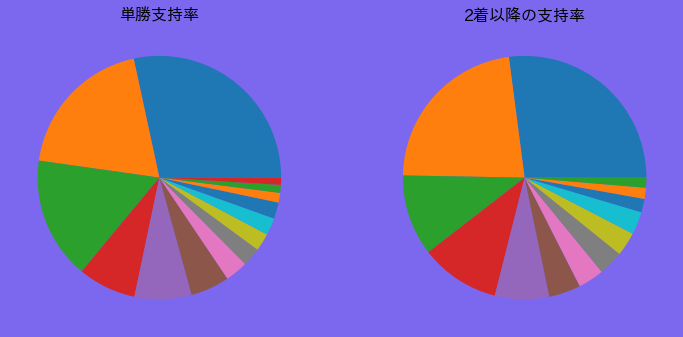

code loading  2019/10/06 00:53:41


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

hanshin = mrc.Rcd("新潟sun")
nakayama = mrc.Rcd("京都sun")
for i in range(1,13):
    hanshin_xxR = hanshin.grc() + str(i).rjust(2,"0")
    RacePiGraph(hanshin_xxR)
    sleep(1)
    nakayama_xxR = nakayama.grc() + str(i).rjust(2,"0")
    RacePiGraph(nakayama_xxR)
    
print("code loading ", datetime.now().strftime("%Y/%m/%d %H:%M:%S"))